5 dòng dữ liệu sau khi đã chuẩn hóa (Sẵn sàng cho GMM):


,R_scaled,F_scaled,M_scaled
customer_id,,,
CUST100002,0.05,0.58,-0.23
CUST100003,0.67,0.58,-1.33
CUST100005,-0.22,-0.83,0.06
CUST100006,1.18,-0.83,-0.42
CUST100007,0.08,0.58,0.41


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


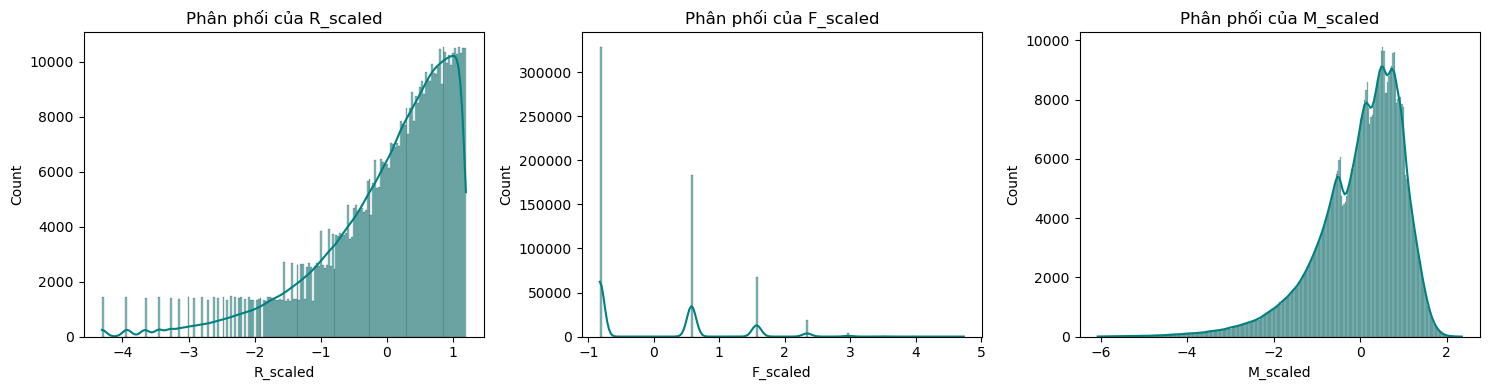

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load dữ liệu từ pipeline
df = pd.read_parquet('data/processed/02_clean_retail_transactions.parquet')

# --- BƯỚC 1: TÍNH TOÁN CHỈ SỐ RFM GỐC ---
# Giả định ngày hiện tại là sau ngày cuối cùng trong data 1 ngày
current_date = df['purchase_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg({
    'purchase_date': lambda x: (current_date - x.max()).days, # Recency
    'purchase_id': 'count',                                 # Frequency
    'total_amount_ngn': 'sum'                               # Monetary
}).rename(columns={
    'purchase_date': 'Recency',
    'purchase_id': 'Frequency',
    'total_amount_ngn': 'Monetary'
})

# --- BƯỚC 2: XỬ LÝ ĐỘ LỆCH (LOG TRANSFORMATION) ---
# Dùng log1p (log của 1 + x) để tránh lỗi nếu có giá trị bằng 0
rfm_log = np.log1p(rfm)

# --- BƯỚC 3: CHUẨN HÓA DỮ LIỆU (STANDARDIZATION) ---
scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm_log)

# Chuyển kết quả về DataFrame để dễ quản lý và đặt tên cột mới
rfm_final = pd.DataFrame(
    rfm_scaled_array,
    index=rfm.index,
    columns=['R_scaled', 'F_scaled', 'M_scaled']
)

# --- BƯỚC 4: KIỂM TRA KẾT QUẢ ---
print("5 dòng dữ liệu sau khi đã chuẩn hóa (Sẵn sàng cho GMM):")
display(rfm_final.head())

# Vẽ biểu đồ kiểm tra phân phối sau khi xử lý
plt.figure(figsize=(15, 4))
for i, col in enumerate(rfm_final.columns):
    plt.subplot(1, 3, i+1)
    sns.histplot(rfm_final[col], kde=True, color='teal')
    plt.title(f'Phân phối của {col}')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Kết hợp bảng RFM gốc và bảng RFM đã scaled thành một bảng bổ trợ duy nhất
# Cả hai bảng này đều có index là customer_id
rfm_features = pd.concat([rfm, rfm_final], axis=1)

# 2. Thực hiện Left Join bảng giao dịch gốc (df) với bảng rfm_features
# Chúng ta join dựa trên cột 'customer_id'
df_dat = df.merge(rfm_features, on='customer_id', how='left')

# 3. Kiểm tra kết quả
print(f"Kích thước bảng mới df_dat: {df_dat.shape}")
print("\nCác cột mới đã được thêm vào:")
print(df_dat[['customer_id', 'Recency', 'Frequency', 'Monetary', 'R_scaled', 'F_scaled', 'M_scaled']].head())

# Hiển thị 5 dòng đầu tiên của bảng tổng hợp df_dat
display(df_dat.head())

Kích thước bảng mới df_dat: (1000000, 27)

Các cột mới đã được thêm vào:
  customer_id  Recency  Frequency   Monetary  R_scaled  F_scaled  M_scaled
0  CUST738296      187          2 1676040.95     -0.05      0.58      0.66
1  CUST566795       65          3 2459054.88     -1.03      1.57      1.01
2  CUST238819       35          3 2486090.27     -1.60      1.57      1.02
3  CUST974466      432          1  471821.12      0.74     -0.83     -0.49
4  CUST686049      200          4 2025133.84      0.02      2.34      0.83


,purchase_id,customer_id,purchase_date,product_category,product_subcategory,quantity,unit_price_ngn,total_amount_ngn,payment_method,channel,...,diff_plus_discount,is_amount_inconsistent,is_outlier_2,is_discount_applied,Recency,Frequency,Monetary,R_scaled,F_scaled,M_scaled
0,PUR0000000,CUST738296,2023-03-07,sports & outdoors,Sports Equipment,5,136977.89,684889.45,cash_on_delivery,online,...,-0.00,0,0,0,187,2,1676040.95,-0.05,0.58,0.66
1,PUR0000001,CUST566795,2024-06-17,health,Supplements,2,297407.47,594814.94,debit_card,mobile_app,...,0.00,0,0,0,65,3,2459054.88,-1.03,1.57,1.01
2,PUR0000002,CUST238819,2024-06-13,baby & kids,Clothing,5,283936.94,1419684.70,cash_on_delivery,in_store,...,0.00,0,0,0,35,3,2486090.27,-1.60,1.57,1.02
3,PUR0000003,CUST974466,2023-09-27,fashion,Jewelry,2,235910.56,471821.12,cash_on_delivery,online,...,0.00,0,0,0,432,1,471821.12,0.74,-0.83,-0.49
4,PUR0000004,CUST686049,2024-05-16,health,Supplements,2,327559.25,655118.50,debit_card,in_store,...,0.00,0,0,0,200,4,2025133.84,0.02,2.34,0.83


In [ ]:
query_2 = """
SELECT * FROM df_dat
where customer_id ='CUST738296'
"""

df_result_2 = duckdb.query(query_2).to_df()
display(df_result_2)

,purchase_id,customer_id,purchase_date,product_category,product_subcategory,quantity,unit_price_ngn,total_amount_ngn,payment_method,channel,...,diff_plus_discount,is_amount_inconsistent,is_outlier_2,is_discount_applied,Recency,Frequency,Monetary,R_scaled,F_scaled,M_scaled
0,PUR0000000,CUST738296,2023-03-07,sports & outdoors,Sports Equipment,5,136977.89,684889.45,cash_on_delivery,online,...,-0.00,0,0,0,187,2,1676040.95,-0.05,0.58,0.66
1,PUR0662257,CUST738296,2024-05-29,fashion,Watches,5,198230.30,991151.50,cash_on_delivery,mobile_app,...,39446.72,1,0,1,187,2,1676040.95,-0.05,0.58,0.66


In [ ]:
# Kiểm tra lại tên các cột trước khi xuất
print(f"Danh sách các cột sẽ xuất: {df_dat.columns.tolist()}")

# Xuất file Parquet
# compression='snappy': giúp file nhẹ hơn nhưng vẫn đọc/ghi nhanh
df_dat.to_parquet('data/processed/04_rfm_features.parquet', compression='snappy', index=False)

print("--- Đã xuất file thành công! ---")

Danh sách các cột sẽ xuất: ['purchase_id', 'customer_id', 'purchase_date', 'product_category', 'product_subcategory', 'quantity', 'unit_price_ngn', 'total_amount_ngn', 'payment_method', 'channel', 'city', 'is_repeat_purchase', 'discount_applied', 'discount_amount_ngn', 'is_outlier', 'calculated_total', 'diff', 'diff_plus_discount', 'is_amount_inconsistent', 'is_outlier_2', 'is_discount_applied', 'Recency', 'Frequency', 'Monetary', 'R_scaled', 'F_scaled', 'M_scaled']
--- Đã xuất file thành công! ---
